In [1]:
import numpy as np 
import pandas as pd 


df_train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e9/train.csv")

In [2]:
df_train.shape

(188533, 13)

In [3]:
df_train.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [4]:
df_train.isna().sum()

id                  0
brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64

count    1.885330e+05
mean     4.387802e+04
std      7.881952e+04
min      2.000000e+03
25%      1.700000e+04
50%      3.082500e+04
75%      4.990000e+04
max      2.954083e+06
Name: price, dtype: float64

Skewness: 20.2685


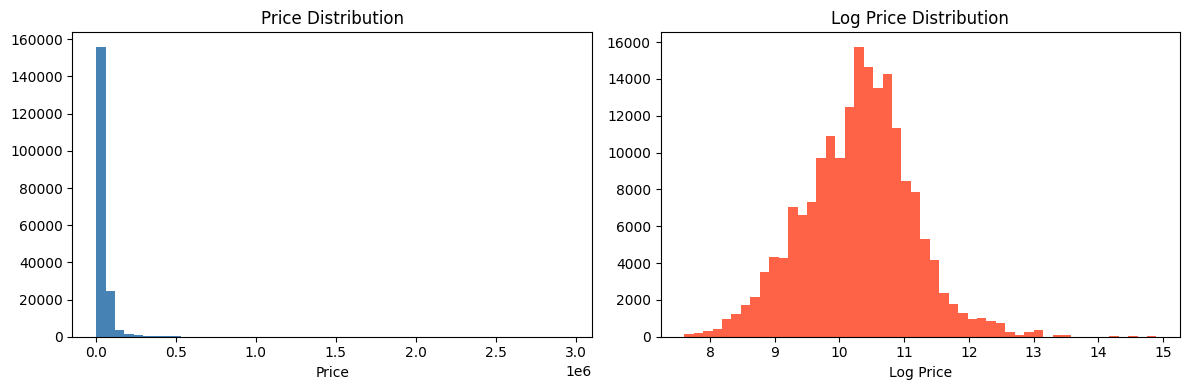

In [5]:
import matplotlib.pyplot as plt
import numpy as np

print(df_train['price'].describe())
print(f"\nSkewness: {df_train['price'].skew():.4f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_train['price'], bins=50, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_train['price']), bins=50, color='tomato')
plt.title('Log Price Distribution')
plt.xlabel('Log Price')
plt.tight_layout()
plt.show()

In [6]:
total = len(df_train)
null_pct = (df_train.isnull().sum() / total * 100).round(1)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
print(null_pct)

clean_title    11.4
fuel_type       2.7
accident        1.3
dtype: float64


In [7]:
mode_cols = ['fuel_type', 'accident', 'clean_title']
for col in mode_cols:
    df_train[col] = df_train[col].fillna(df_train[col].mode()[0])

print(f"Nulls: {df_train.isnull().sum().sum()}")
print(f"Shape: {df_train.shape}")

Nulls: 0
Shape: (188533, 13)


In [ ]:
df_train['horsepower']      = df_train['engine'].str.extract(r'(\d+\.?\d*)HP').astype(float)
df_train['displacement']    = df_train['engine'].str.extract(r'(\d+\.?\d*)L').astype(float)
df_train['cylinders']       = df_train['engine'].str.extract(r'(\d+)\s*Cylinder').astype(float)

for col in ['horsepower', 'displacement', 'cylinders']:
    df_train[col] = df_train[col].fillna(df_train[col].median())

df_train['car_age']          = 2024 - df_train['model_year']
df_train['mileage_per_year'] = df_train['milage'] / (df_train['car_age'] + 1)

luxury_brands = ['Mercedes-Benz', 'BMW', 'Audi', 'Porsche', 'Lexus',
                 'Jaguar', 'Land Rover', 'Maserati', 'Bentley',
                 'Rolls-Royce', 'Ferrari', 'Lamborghini', 'Aston Martin']
df_train['is_luxury']    = df_train['brand'].isin(luxury_brands).astype(int)
df_train['has_accident'] = (df_train['accident'] == 'At least 1 accident or damage reported').astype(int)

df_train['price'] = np.log1p(df_train['price'])

print(f"Price range: {df_train['price'].min():.2f} to {df_train['price'].max():.2f}")
print(f"Sample: {df_train['price'].values[:3]}")

Price range: 7.60 to 14.90
Sample: [8.34307787 8.51719319 9.53971606]


In [9]:
from sklearn.model_selection import train_test_split
X = df_train.drop(columns=['price'])
y = df_train['price']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Val  : {X_val.shape}")
print(f"Test : {X_test.shape}")

Train: (120660, 19)
Val  : (30166, 19)
Test : (37707, 19)


In [ ]:
brand_mean = y_train.groupby(X_train['brand']).mean()
model_mean = y_train.groupby(X_train['model']).mean()
trans_mean = y_train.groupby(X_train['transmission']).mean()

global_mean = y_train.mean()

X_train['brand_encoded']        = X_train['brand'].map(brand_mean).fillna(global_mean)
X_train['model_encoded']        = X_train['model'].map(model_mean).fillna(global_mean)
X_train['transmission_encoded'] = X_train['transmission'].map(trans_mean).fillna(global_mean)

X_val['brand_encoded']        = X_val['brand'].map(brand_mean).fillna(global_mean)
X_val['model_encoded']        = X_val['model'].map(model_mean).fillna(global_mean)
X_val['transmission_encoded'] = X_val['transmission'].map(trans_mean).fillna(global_mean)

X_test['brand_encoded']        = X_test['brand'].map(brand_mean).fillna(global_mean)
X_test['model_encoded']        = X_test['model'].map(model_mean).fillna(global_mean)
X_test['transmission_encoded'] = X_test['transmission'].map(trans_mean).fillna(global_mean)

print("Correlation with price:")
for col in ['brand_encoded', 'model_encoded', 'transmission_encoded']:
    corr = X_train[col].corr(y_train)
    print(f"{col:25} {corr:+.3f}")

Correlation with price:
brand_encoded             +0.363
model_encoded             +0.675
transmission_encoded      +0.490


In [ ]:
drop_cols = ['brand', 'model', 'transmission', 'engine', 
             'model_year', 'accident', 'clean_title', 'id']

X_train = X_train.drop(columns=drop_cols)
X_val   = X_val.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

print(X_train.select_dtypes(include='object').columns.tolist())
print(f"Shape: {X_train.shape}")

['fuel_type', 'ext_col', 'int_col']
Shape: (120660, 14)


In [12]:
for col in ['fuel_type', 'ext_col', 'int_col']:
    print(f"{col:10} {X_train[col].nunique()} unique values")

fuel_type  7 unique values
ext_col    319 unique values
int_col    156 unique values


In [13]:
ext_mean = y_train.groupby(X_train['ext_col']).mean()
int_mean = y_train.groupby(X_train['int_col']).mean()

for split_X in [X_train, X_val, X_test]:
    split_X['ext_col_encoded'] = split_X['ext_col'].map(ext_mean).fillna(global_mean)
    split_X['int_col_encoded'] = split_X['int_col'].map(int_mean).fillna(global_mean)
    split_X = split_X.drop(columns=['ext_col', 'int_col'])

X_train = X_train.drop(columns=['ext_col', 'int_col'])
X_val   = X_val.drop(columns=['ext_col', 'int_col'])
X_test  = X_test.drop(columns=['ext_col', 'int_col'])

X_train = pd.get_dummies(X_train, columns=['fuel_type'])
X_val   = pd.get_dummies(X_val,   columns=['fuel_type'])
X_test  = pd.get_dummies(X_test,  columns=['fuel_type'])

X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Shape: {X_train.shape}")
print(f"Nulls: {X_train.isnull().sum().sum()}")

Shape: (120660, 20)
Nulls: 0


In [14]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train : {X_train_scaled.shape}")
print(f"Val   : {X_val_scaled.shape}")
print(f"Test  : {X_test_scaled.shape}")

Train : (120660, 20)
Val   : (30166, 20)
Test  : (37707, 20)


In [ ]:
import torch
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values)

X_val_tensor   = torch.FloatTensor(X_val_scaled)
y_val_tensor   = torch.FloatTensor(y_val.values)

X_test_tensor  = torch.FloatTensor(X_test_scaled)
y_test_tensor  = torch.FloatTensor(y_test.values)

print(f"X_train: {X_train_tensor.shape} | dtype: {X_train_tensor.dtype}")
print(f"y_train: {y_train_tensor.shape} | dtype: {y_train_tensor.dtype}")
print(f"\nFirst row of X_train: {X_train_tensor[0][:5]}...")  
print(f"First label: {y_train_tensor[0]}")

X_train: torch.Size([120660, 20]) | dtype: torch.float32
y_train: torch.Size([120660]) | dtype: torch.float32

First row of X_train: tensor([-1.2472, -0.1108, -0.2145, -0.2125, -1.2683])...
First label: 10.596610069274902


In [16]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

batch_size = 256

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Batch size    : {batch_size}")
print(f"\nEach batch: {batch_size}")

X_batch, y_batch = next(iter(train_loader))
print(f"\nOne batch X shape: {X_batch.shape}")
print(f"One batch y shape: {y_batch.shape}")

Train batches : 472
Val batches   : 118
Batch size    : 256

Each batch: 256

One batch X shape: torch.Size([256, 20])
One batch y shape: torch.Size([256])


In [ ]:
import torch.nn as nn
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CarsnetV2(nn.Module):
    def __init__(self, input_size):
        super(CarsnetV2, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.network(x)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values)
X_val_tensor   = torch.FloatTensor(X_val_scaled)
y_val_tensor   = torch.FloatTensor(y_val.values)
X_test_tensor  = torch.FloatTensor(X_test_scaled)
y_test_tensor  = torch.FloatTensor(y_test.values)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor,   y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

model     = CarsnetV2(input_size=X_train.shape[1]).to(device)
criterion = nn.HuberLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 11,393


In [19]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()  
    total_loss = 0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        logits = model(X_batch).squeeze()
        
        loss = criterion(logits, y_batch)
        
        optimizer.zero_grad()

        loss.backward()
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader) 

In [20]:
def evaluate(model, loader, criterion, device):
    model.eval()   
    total_loss = 0
    all_preds  = []
    all_labels = []
    
    with torch.no_grad():

        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits      = model(X_batch).squeeze()
            loss        = criterion(logits, y_batch)
            
            predictions = logits

            
            total_loss += loss.item()
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
       
    
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)

In [21]:
import numpy as np

n_epochs      = 50
best_val_loss = float('inf')  
patience      = 5
patience_counter = 0

train_losses = []
val_losses   = []

for epoch in range(n_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # These must be INSIDE the for loop
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} | "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"Patience: {patience_counter}/{patience}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(torch.load('best_model.pth'))
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch   5/50 | Train: 0.3863 | Val: 0.1265 | Patience: 1/5
Epoch  10/50 | Train: 0.3210 | Val: 0.1193 | Patience: 1/5
Epoch  15/50 | Train: 0.2777 | Val: 0.1138 | Patience: 0/5
Epoch  20/50 | Train: 0.2592 | Val: 0.1133 | Patience: 3/5

Early stopping at epoch 22

Best val loss: 0.1128


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

test_preds_real  = np.expm1(test_preds)
test_labels_real = np.expm1(test_labels)

rmse = np.sqrt(mean_squared_error(test_labels_real, test_preds_real))
mae  = mean_absolute_error(test_labels_real, test_preds_real)
r2   = r2_score(test_labels_real, test_preds_real)

print(f"RMSE : ${rmse:,.0f}")
print(f"MAE  : ${mae:,.0f}")
print(f"R²   : {r2:.4f}")

r2_log = r2_score(test_labels, test_preds)
print(f"R² (log scale): {r2_log:.4f}")

RMSE : $69,374
MAE  : $17,574
R²   : 0.1346
R² (log scale): 0.6392


In [27]:
mask = test_labels_real < 200000
r2_filtered   = r2_score(test_labels_real[mask], test_preds_real[mask])
rmse_filtered = np.sqrt(mean_squared_error(test_labels_real[mask], test_preds_real[mask]))
mae_filtered  = mean_absolute_error(test_labels_real[mask], test_preds_real[mask])

print(f"Cars < $200k ({mask.sum()} cars):")
print(f"R²   : {r2_filtered:.4f}")
print(f"RMSE : ${rmse_filtered:,.0f}")
print(f"MAE  : ${mae_filtered:,.0f}")

Cars < $200k (37031 cars):
R²   : 0.4944
RMSE : $21,077
MAE  : $12,197
